## 2.1 Exploratory Analysis

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

In [2]:
# Load the dataset
data = pd.read_csv('transformer_data.csv')

In [8]:
data.columns

Index(['time', 'Y', 'Ta', 'S', 'I'], dtype='str')

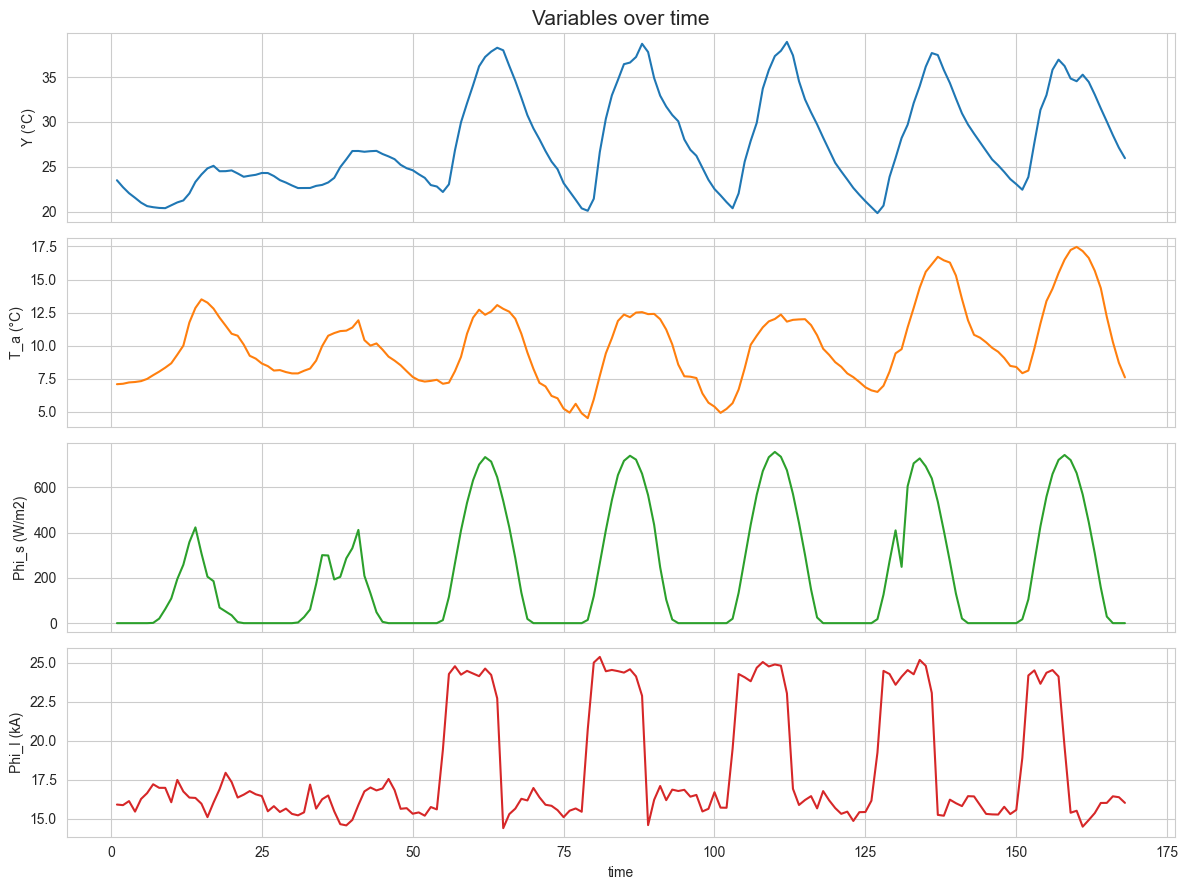

In [16]:
# Plot the variables in four stacked panels with shared time axis
sns.set_style('whitegrid')
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)

axes[0].plot(data['time'], data['Y'], color='C0')
axes[0].set_ylabel('Y (°C)')
axes[0].set_title('Variables over time', fontsize=15)

axes[1].plot(data['time'], data['Ta'], color='C1')
axes[1].set_ylabel('T_a (°C)')

axes[2].plot(data['time'], data['S'], color='C2')
axes[2].set_ylabel('Phi_s (W/m2)')

axes[3].plot(data['time'], data['I'], color='C3')
axes[3].set_ylabel('Phi_I (kA)')
axes[3].set_xlabel('time')

plt.tight_layout()
plt.show()

## 2.2 Estimate a 1-dimensional state-space model

The model is:

$$X_{t+1} = A X_t + B u_t + G e_{1,t}, \quad e_{1,t} \sim \mathcal{N}(0,1)$$
$$Y_t = C X_t + e_{2,t}, \quad e_{2,t} \sim \mathcal{N}(0, \sigma_y^2)$$

where $u_t = [T_{a,t},\, \Phi_{s,t},\, \Phi_{I,t}]^T$. With $C = 1$ (direct observation of state), the parameters to estimate are $A$, $B \in \mathbb{R}^{1\times3}$, $G$, and $\sigma_y$.

In [ ]:
from scipy.optimize import minimize
from scipy.stats import norm

def kf_loglik(par, Y, U):
    """
    Kalman filter log-likelihood for the 1D state-space model:
      X_{t+1} = A*X_t + B*u_t + G*e1_t,   e1_t ~ N(0,1)
      Y_t     = X_t + e2_t,                e2_t ~ N(0, sigma_y^2)

    par = [A, B1, B2, B3, log_G, log_sigma_y]
    """
    A       = par[0]
    B       = par[1:4]
    G       = np.exp(par[4])       # positive via log-transform
    sigma_y = np.exp(par[5])       # positive via log-transform

    Q = G**2          # system noise variance
    R = sigma_y**2    # observation noise variance

    T = len(Y)
    x = Y[0]          # initial state = first observation
    P = 10.0          # initial state covariance (diffuse prior)

    logL = 0.0
    for t in range(T):
        # --- Prediction ---
        x_pred = A * x + np.dot(B, U[t])
        P_pred = A**2 * P + Q

        # --- Innovation ---
        innov = Y[t] - x_pred          # C = 1, so y_pred = x_pred
        S     = P_pred + R             # innovation variance

        # --- Log-likelihood contribution ---
        logL -= 0.5 * (np.log(2 * np.pi * S) + innov**2 / S)

        # --- Update ---
        K = P_pred / S                 # Kalman gain  (C = 1)
        x = x_pred + K * innov
        P = (1.0 - K) * P_pred

    return logL


def kf_filter(par, Y, U):
    """Run the Kalman filter and return innovations for diagnostics."""
    A       = par[0]
    B       = par[1:4]
    G       = np.exp(par[4])
    sigma_y = np.exp(par[5])
    Q = G**2;  R = sigma_y**2

    T = len(Y)
    x, P = Y[0], 10.0
    innovations, S_vals, x_filt = [], [], []

    for t in range(T):
        x_pred = A * x + np.dot(B, U[t])
        P_pred = A**2 * P + Q
        innov  = Y[t] - x_pred
        S      = P_pred + R
        K      = P_pred / S
        x      = x_pred + K * innov
        P      = (1.0 - K) * P_pred
        innovations.append(innov)
        S_vals.append(S)
        x_filt.append(x)

    return np.array(innovations), np.array(S_vals), np.array(x_filt)

In [ ]:
# --- Prepare data ---
Y = data['Y'].values
U = data[['Ta', 'S', 'I']].values

# --- Initial parameter guess ---
# par = [A, B1(Ta), B2(S), B3(I), log_G, log_sigma_y]
par0 = np.array([0.95, 0.04, 1e-4, 1e-3, np.log(0.5), np.log(0.5)])

# --- Maximise log-likelihood (minimise negative) ---
result = minimize(
    lambda p: -kf_loglik(p, Y, U),
    par0,
    method='L-BFGS-B',
    options={'maxiter': 2000, 'ftol': 1e-12, 'gtol': 1e-8}
)

par_hat = result.x
A_hat       = par_hat[0]
B_hat       = par_hat[1:4]
G_hat       = np.exp(par_hat[4])
sigma_y_hat = np.exp(par_hat[5])

print(f"Convergence: {result.message}")
print(f"\nEstimated parameters:")
print(f"  A        = {A_hat:.6f}")
print(f"  B (Ta)   = {B_hat[0]:.6f}")
print(f"  B (S)    = {B_hat[1]:.6f}")
print(f"  B (I)    = {B_hat[2]:.6f}")
print(f"  G        = {G_hat:.6f}  (system noise scale)")
print(f"  sigma_y  = {sigma_y_hat:.6f}  (observation noise std)")

# --- Information criteria ---
k      = len(par_hat)
logL   = kf_loglik(par_hat, Y, U)
n_obs  = len(Y)
AIC    = 2*k - 2*logL
BIC    = k*np.log(n_obs) - 2*logL
print(f"\nLog-likelihood: {logL:.4f}")
print(f"AIC: {AIC:.4f}")
print(f"BIC: {BIC:.4f}")

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import probplot

# --- Run filter at estimated parameters to get innovations ---
innovations, S_vals, x_filt = kf_filter(par_hat, Y, U)

# Standardised innovations (should be N(0,1) if model is correct)
std_innov = innovations / np.sqrt(S_vals)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Residuals over time
ax = axes[0, 0]
ax.plot(data['time'].values, std_innov, color='C0', linewidth=0.7)
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.axhline( 1.96, color='C3', linewidth=0.8, linestyle=':', label='±1.96')
ax.axhline(-1.96, color='C3', linewidth=0.8, linestyle=':')
ax.set_title('Standardised innovations over time')
ax.set_xlabel('time');  ax.set_ylabel('Standardised innovation')
ax.legend()

# 2. ACF of standardised innovations
plot_acf(std_innov, lags=40, ax=axes[0, 1], title='ACF of standardised innovations')
axes[0, 1].set_xlabel('Lag')

# 3. PACF of standardised innovations
plot_pacf(std_innov, lags=40, ax=axes[1, 0],
          title='PACF of standardised innovations', method='ywm')
axes[1, 0].set_xlabel('Lag')

# 4. QQ-plot
probplot(std_innov, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('QQ-plot of standardised innovations')

plt.tight_layout()
plt.show()

In [ ]:
# --- Filtered state vs observed ---
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(data['time'].values, Y,      color='C0', linewidth=0.8, label='Observed $Y_t$')
ax.plot(data['time'].values, x_filt, color='C1', linewidth=0.8, label='Filtered state $\hat{X}_{t|t}$')
ax.set_title('Observed vs. filtered state')
ax.set_xlabel('time');  ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.show()